# I - Libraries

In [1]:
# Import libraries
import numpy as np                                      # Calculating tools
import pandas as pd                                     # Data manipulation
import scipy.stats as stats                             # Statistics tools
import matplotlib.pyplot as plt                         # Data visualization
import seaborn as sns                                   # Modern data visualization
import plotly.graph_objects as go                       # Interactive visualization

from sklearn.preprocessing import OrdinalEncoder, StandardScaler, LabelEncoder   # Encode categorical variable,  Data normalization
from sklearn.model_selection import train_test_split                             # Create train, test set         
from sklearn import datasets                                                     # Some sample data sets 
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA      # LDA model
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis as QDA   # QDA model
from sklearn.neighbors import KNeighborsClassifier                               # kNN model 
from sklearn.neighbors import KNeighborsClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import cross_val_score

import statsmodels.api as sm                     # Statistical models
import statsmodels.formula.api as smf            # Statistical models with formula supports
import ISLP 


# II- Data Exploration & Cleaning

## A) Loading the data

In [33]:
train = pd.read_csv('Data/train.csv', index_col=0)
train_labels = pd.read_csv('Data/train_labels.csv', index_col=0)
test = pd.read_csv('Data/test.csv', index_col=0)

C:\Users\Source\AppData\Local\Temp\ipykernel_2844\2079969306.py:1: DtypeWarning: Columns (14742,14743,14749,14750,14751,14753,14754,14756,14759,14760,14761,14763,14768,14770,14774,14777,14780,14781,14782,14790,14792,14798,14799,14801,14805,14806,14807,14810,14812,14818,14819,14820,14825,14829,14833,14835,14837,14844,14845,14851,14852,14856,14862,14872,14877,14879,14880,14882,14883,14884,14887,14889,14891,14895,14897,14898,14901,14905,14907,14915,14917,14918,14919,14927,14929,14932,14933,14937,14938,14940,14943,14945,14948,14952,14955,14958,14959,14971,14973,14981,14997,14999) have mixed types. Specify dtype option on import or set low_memory=False.
  train = pd.read_csv('Data/train.csv', index_col=0)
C:\Users\Source\AppData\Local\Temp\ipykernel_2844\2079969306.py:3: DtypeWarning: Columns (14742,14743,14749,14750,14751,14753,14754,14756,14759,14760,14761,14763,14768,14770,14774,14777,14780,14781,14782,14790,14792,14798,14799,14801,14805,14806,14807,14810,14812,14818,14819,14820,14825,14

We verify that the data was loaded correclty

In [34]:
train.head(3)

,Var1,Var2,Var3,Var4,Var5,Var6,Var7,Var8,Var9,Var10,...,Var14991,Var14992,Var14993,Var14994,Var14995,Var14996,Var14997,Var14998,Var14999,Var15000
ID,,,,,,,,,,,,,,,,,,,,,
502504,0,0,0,0,6,0,0.0,0,0,0,...,NaN,NaN,Y562h9T,NaN,Q8_a,Xjzr,NaN,NaN,NaN,NaN
197332,0,0,0,0,0,0,0.0,0,0,0,...,NaN,NaN,NyGn9rV,NaN,Q8_a,NBRvrWWx0Z,NaN,NaN,NaN,NaN
277830,0,0,0,0,0,0,0.0,0,0,0,...,NaN,NaN,Kbs60Tf,NaN,Q8_a,NBRvrWWx0Z,NaN,GD6M5hO,NaN,NaN


In [35]:
train_labels.head(3)

,Target_appetency
ID,
502504,0
197332,0
277830,0


In [36]:
test.head(3)

,Var1,Var2,Var3,Var4,Var5,Var6,Var7,Var8,Var9,Var10,...,Var14991,Var14992,Var14993,Var14994,Var14995,Var14996,Var14997,Var14998,Var14999,Var15000
ID,,,,,,,,,,,,,,,,,,,,,
877149,0,0,0,0,0,0,0.0,0,0,0,...,NaN,NaN,oHCnpDP,NaN,KttQ,NBRvrWWx0Z,NaN,GD6M5hO,NaN,NaN
109603,0,0,0,0,0,0,0.0,0,0,0,...,NaN,NaN,WHgQeH3,NaN,KttQ,lGxM0UqL0k,NaN,NaN,NaN,NaN
560424,0,0,0,0,0,0,0.0,0,0,0,...,NaN,NaN,COVmcoL,NaN,Q8_a,NBRvrWWx0Z,NaN,NaN,NaN,NaN


In [ ]:
# Merging the training set 

#train = train.merge(train_labels, on='ID', how='left')

## B) Data Exploration

In [59]:
def explore(dataset, name = "dataset"):
    print(f'{name} set : ')
    print(f'Rows    : {dataset.shape[0]}')
    print(f'Columns : {dataset.shape[1]}')
    print(f'Dtypes breakdown:')
    print(dataset.dtypes.value_counts())

In [60]:
# Train set
explore(train, name = "Train")


Train set : 
Rows    : 30000
Columns : 15000
Dtypes breakdown:
int64      13414
float64     1397
object       189
Name: count, dtype: int64


In [63]:
# Train Labels
explore(train_labels, name='Train Labels')

Train Labels set : 
Rows    : 30000
Columns : 1
Dtypes breakdown:
int64    1
Name: count, dtype: int64


In [61]:
# Test set
explore(test, name = 'Test')

Test set : 
Rows    : 20000
Columns : 15000
Dtypes breakdown:
int64      13414
float64     1397
object       189
Name: count, dtype: int64


We notice that we only have 189 categorical variables.  
However, according to the data description, we are supossed to find 260 categorical variables.  
Hence, we need to check where the problem is and correct the problem accordingly

In [79]:
# We verify the dtype of the 260 categorical variables
print('Train : ' , train.iloc[:, 14741:].dtypes.unique())
print('Test : ', test.iloc[:, 14741:].dtypes.unique())

Train :  [dtype('O') dtype('float64')]
Test :  [dtype('O') dtype('float64')]


We can see that some of these features are casted as floats. We need to cast them back as objects

In [91]:
# Casting for train
train[train.columns[14741 :]] = train[train.columns[14741 :]].astype('object')


# Casting for test
test[test.columns[14741 :]] = test[test.columns[14741 :]].astype('object')

# Checking 

print('Train : ' , train.iloc[:, 14741:].dtypes.unique())
print('Test : ', test.iloc[:, 14741:].dtypes.unique())

Train :  [dtype('O')]
Test :  [dtype('O')]


In [96]:
train_labels

,Target_appetency
ID,
502504,0
197332,0
277830,0
247676,0
972007,0
...,...
625358,0
382670,0
209811,0


C:\Users\Source\AppData\Local\Temp\ipykernel_2844\3934677615.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=dist_pct,


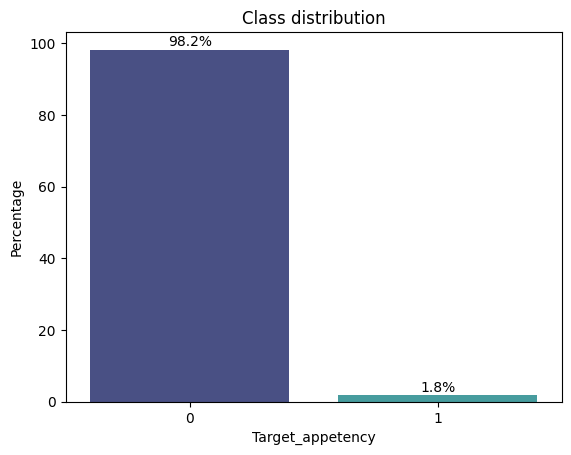

In [ ]:
# Checking class balance

dist_pct    =  train_labels['Target_appetency'].value_counts(normalize=True) * 100
dist_pct = dist_pct.reset_index()
dist_pct.columns = ['Target_appetency', 'Percentage']

ax = sns.barplot(data=dist_pct,
            x = 'Target_appetency',
            y = 'Percentage',
            palette='mako')

for p in ax.patches:
    ax.text(
        x=p.get_x() + p.get_width()/2,  # center of bar
        y=p.get_height() + 1,           # slightly above bar
        s=f'{p.get_height():.1f}%',     # text
        ha='center'
    )

plt.title('Class distribution')
plt.show()

We notice that the data is **highly imbalanced.**  
This will be handled later when modeling.

## C) Data Cleaning

In [11]:
# Only keeping the first 10 columns
train = train.iloc[:, :10]
test = test.iloc[:, :10]

In [12]:
X_train = train.fillna(0).values
X_test = test.fillna(0).values

In [13]:
y = train_labels['Target_appetency']
y.head()

ID
502504    0
197332    0
277830    0
247676    0
972007    0
Name: Target_appetency, dtype: int64

In [14]:
# Train KNN
knn = KNeighborsClassifier(n_neighbors=5, n_jobs=-1)
knn.fit(X_train, y)
preds = knn.predict_proba(X_test)[:, 1]

In [15]:
scores = cross_val_score(knn, X_train, y, cv=5, scoring='roc_auc')
print(f"AUC: {scores.mean():.4f}")

AUC: 0.4998


In [ ]:
# Submission
submission = pd.DataFrame({'Target_appetency': preds}, index=test.index)
submission.index.name = 'ID'
submission.to_csv('submission.csv')